In [1]:
NAME = "Radin Cheraghi"
STID = "401105815"


# Offline RL project: DDPG + Behavior Cloning (DDPG+BC)

## Learning Objectives

By the end of this notebook, you will be able to:

- Explain **offline RL vs. online RL** and **extrapolation error**.
- Implement, from a stated objective (not a supplied formula), DDPG's **TD target**, its
  **target-network update rule**, and a **BC-regularized actor loss with adaptive weighting**.
- Design and run a **controlled ablation** that separates the effect of state normalization from
  the effect of BC regularization.
- Support an empirical claim about offline RL with **multi-seed statistics**, not a single run.

**References**

- Fujimoto & Gu, *"A Minimalist Approach to Offline Reinforcement Learning"* (TD3+BC)
- Wu et al., *"Behavior Regularized Offline Reinforcement Learning"* (BRAC)
- An et al., *"Uncertainty-Based Offline Reinforcement Learning with Diversified Q-Ensemble"*

## Time Budget (benchmarked, not guessed)

| Phase | Work | Est. wall-clock |
|---|---|---|
| Dataset collection | 200 episodes x 200 steps, heuristic controller | ~30-45s |
| **Required**: 3-config x 3-seed comparison | 9 runs x 10,000 steps | ~11-13 min |
| **Required**: alpha sweep (3 values, 1 seed) | 3 runs x 5,000 steps | ~2-3 min |
| Eval rollouts (periodic, all runs) | cheap env, no NN grad | ~2-4 min |
| **Required compute subtotal** | | **~17-22 min** |
| Interpreting results + writing required answers | | ~35-50 min |
| **Required total** | | **~55-75 min** |
| *Optional* extra credit (dataset-size/noise sweep) | | +~3 min compute, +~15 min write-up |
| *Optional* extra credit (2-critic ensemble) | | +~10-15 min implementation |

These compute estimates were measured directly on a single CPU core running this exact
architecture (3->256->256->1 actor, 4->256->256->1 critic, batch 256): ~141 gradient
steps/second. A free-tier GPU will typically be similar or only modestly faster for a network
this small -- see the device note below.


## How to Use This Notebook

- Cells marked with `# TODO` raise `NotImplementedError` until you fill them in. Downstream cells
  assume the TODO above them is implemented correctly and will fail loudly (not silently) if it
  isn't -- this is intentional, so a broken implementation is caught immediately instead of
  producing a plausible-looking but wrong plot several cells later.
- Cells marked **"Discussion question (required)"** contain a `**Your answer:**` placeholder.
  These are graded on the reasoning you give, not on matching one specific answer.
- The final section contains the grading rubric and a submission checklist.


## 1. Background & Motivation

### Offline RL (Batch RL)

In standard (online) RL, an agent interacts with the environment, collects new data as it learns,
and continually updates its behavior. **Offline RL** instead assumes we are given a *fixed
dataset* $\mathcal{D} = \{(s_i, a_i, r_i, s_i')\}$, collected once by some (possibly suboptimal,
possibly stochastic) **behavior policy** $\pi_\beta$. The agent must learn a good policy **purely
from this static dataset**, without any further interaction with the environment during training.

### Extrapolation Error

Off-policy actor-critic methods like DDPG estimate $Q_\phi(s,a)$ and improve the policy by pushing
it toward actions that maximize $Q_\phi$. Online, any overestimation of $Q$ for a bad action gets
corrected the next time that action is actually tried in the environment. **Offline**, we no
longer get that correction: the critic is queried on actions $\pi_\theta(s)$ chosen by the
*current* policy, which can drift toward actions that are **out-of-distribution (OOD)** relative
to the dataset. The critic has never seen these actions, so its estimate there is unreliable --
often erroneously high. The policy then chases these overestimated values, compounding the error.
This is **extrapolation error**.

### Behavior Regularization

A general fix is to **regularize** the learned policy to stay close to the behavior policy that
generated the data, so the critic is (mostly) only ever queried near the data distribution, where
its estimates are trustworthy. **BRAC** (Wu et al., 2019) formalizes this as a family of
algorithms that add a divergence penalty between $\pi_\theta$ and an estimate of $\pi_\beta$ to
the actor objective. **TD3+BC** (Fujimoto & Gu, 2021) shows that a much simpler regularizer -- a
plain behavior-cloning (MSE) term between the policy's action and the logged action -- already
recovers most of the benefit, plus feature normalization of the states. We adapt this recipe to
DDPG here.

### Normalization Is Not the Same Thing as BC

This is worth stating as a general experimental-design principle, not just a notebook-specific
note: TD3+BC changes **two** things relative to vanilla DDPG -- it adds the BC term, *and* it
normalizes states. If you compare "vanilla DDPG" against "DDPG+BC+normalization" and see a gap,
you cannot yet say *which* of those two changes caused it. This notebook is built so you separate
them explicitly (Section 7).

### A Different Angle: Uncertainty-Based Penalization

An orthogonal family of methods (e.g. An et al., 2021) does not regularize the policy directly.
Instead, they train an **ensemble of critics** and penalize actions where the critics *disagree*
(high epistemic uncertainty), which tends to happen for OOD actions. This is more
compute-intensive than the BC-based approach; we treat it only conceptually here, with a tiny
optional 2-critic version as an extra-credit exercise.


## 2. Methodological Notes (read before you start coding)

**Device.** For a network this small (three linear layers, a few hundred thousand parameters),
GPU kernel-launch overhead can dominate actual compute, so a T4 GPU may not be faster than CPU
here. If your run isn't faster on GPU, that's expected, not a bug.

**Seeding.** Two *independent* random number generators are used per run:
- `torch.manual_seed(seed)` controls network initialization.
- A dedicated `numpy.random.Generator` (created by `make_sample_rng(seed)`) controls replay-buffer
  minibatch sampling.

For a given seed, we reuse the **same** sampling RNG seed across all three ablation
configurations in Section 7, so all three configurations see the **exact same sequence of sampled
minibatches** for that seed. This removes sampling-order noise as a confound between
configurations, leaving only the algorithmic differences (normalization on/off, BC on/off) as the
source of any observed gap.


In [2]:
# If gymnasium / torch / matplotlib are not yet installed in this environment,
# uncomment the line below (covers common Colab/Kaggle version quirks).
# !pip install -q "gymnasium[classic-control]" torch numpy matplotlib

In [3]:
import random
import copy

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import gymnasium as gym

SEED_LIST = [0, 1, 2]  # the 3 seeds used for every required multi-seed run

random.seed(SEED_LIST[0])
np.random.seed(SEED_LIST[0])
torch.manual_seed(SEED_LIST[0])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}  (see Section 2 above for why this may not matter much here)")


def make_sample_rng(seed):
    '''Dedicated RNG for replay-buffer sampling, kept separate from torch's RNG
    (which governs network init) so we can reuse the identical sampling sequence
    across ablation configurations at a given seed -- see Section 2.'''
    return np.random.default_rng(seed)

Using device: cuda  (see Section 2 above for why this may not matter much here)


In [4]:
ENV_NAME = "Pendulum-v1"

env = gym.make(ENV_NAME)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])

print(f"Environment: {ENV_NAME}")
print(f"State dim: {state_dim}, Action dim: {action_dim}, Max action magnitude: {max_action}")
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

Environment: Pendulum-v1
State dim: 3, Action dim: 1, Max action magnitude: 2.0
Observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action space: Box(-2.0, 2.0, (1,), float32)


## 3. Offline Dataset Collection

A **behavior policy** $\pi_\beta$ is whatever policy generated the historical data we are given.
Crucially, in the offline setting we do **not** get to choose or improve $\pi_\beta$; we simply
inherit whatever dataset it produced.

We use a **hand-designed swing-up controller with injected Gaussian action noise** as our
behavior policy, to mimic a *medium-quality* logged dataset. We roll it out for a fixed number of
episodes to build a **static replay buffer**.

**Important:** once this dataset is collected, we will not call `env.step()` again for *training*
purposes -- only for periodically *evaluating* the learned policy, which is standard offline-RL
protocol.


In [5]:
class ReplayBuffer:
    '''Fixed-capacity replay buffer for offline RL.

    Stores transitions (s, a, r, s', done) as numpy arrays and supports random
    sampling of minibatches as torch tensors on `device`, using an explicitly
    passed RNG (see Section 2 for why we avoid the global np.random state).
    '''

    def __init__(self, state_dim, action_dim, capacity=200_000):
        self.capacity = capacity
        self.ptr = 0
        self.size = 0

        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, action_dim), dtype=np.float32)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)

    def add(self, state, action, reward, next_state, done):
        self.states[self.ptr] = state
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_states[self.ptr] = next_state
        self.dones[self.ptr] = done

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size, rng):
        '''Sample a minibatch using the given numpy.random.Generator `rng` (not
        the global numpy RNG), so callers can control/replay the exact sampling
        sequence -- see Section 2 and Section 7.'''
        idx = rng.integers(0, self.size, size=batch_size)
        return (
            torch.as_tensor(self.states[idx], device=device),
            torch.as_tensor(self.actions[idx], device=device),
            torch.as_tensor(self.rewards[idx], device=device),
            torch.as_tensor(self.next_states[idx], device=device),
            torch.as_tensor(self.dones[idx], device=device),
        )

    def __len__(self):
        return self.size

In [6]:
def behavior_policy(state, noise_std=0.6, max_action=max_action):
    '''A hand-designed, noisy 'swing-up + stabilize' controller for Pendulum-v1.

    Pendulum-v1's observation is [cos(theta), sin(theta), theta_dot], where
    theta=0 is the upright (goal) position. We use a simple heuristic:
      - Far from upright: apply torque in the direction of current motion
        (a crude 'pump energy' swing-up rule).
      - Near upright: apply a PD-control torque to stabilize.
    Gaussian noise is added to make the behavior policy stochastic and
    suboptimal, similar to a 'medium'-quality dataset.
    '''
    cos_th, sin_th, theta_dot = state
    theta = np.arctan2(sin_th, cos_th)

    if abs(theta) > 1.0:
        action = max_action * np.sign(theta_dot + 1e-8)
    else:
        kp, kd = 6.0, 1.0
        action = -kp * theta - kd * theta_dot

    action = action + np.random.normal(0, noise_std)
    action = np.clip(action, -max_action, max_action)
    return np.array([action], dtype=np.float32)

Collected 40000 transitions from 200 episodes.
Behavior policy return: mean=-890.2, std=485.6, min=-1286.8, max=-1.7


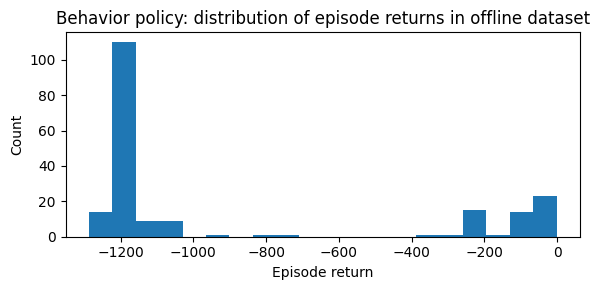

In [7]:
def collect_offline_dataset(env, n_episodes=200, noise_std=0.6, seed=SEED_LIST[0]):
    buffer = ReplayBuffer(state_dim, action_dim)
    episode_returns = []

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        ep_return = 0.0
        done = False
        truncated = False

        while not (done or truncated):
            action = behavior_policy(state, noise_std=noise_std)
            next_state, reward, done, truncated, _ = env.step(action)
            # We store true `done` separately from `truncated` (time-limit
            # cutoff): for bootstrapping we only want to zero out the target
            # on true termination, not on a time-limit truncation.
            buffer.add(state, action, reward, next_state, float(done))
            state = next_state
            ep_return += reward

        episode_returns.append(ep_return)

    return buffer, episode_returns


offline_buffer, behavior_returns = collect_offline_dataset(env, n_episodes=200, noise_std=0.6)

print(f"Collected {len(offline_buffer)} transitions from {len(behavior_returns)} episodes.")
print(f"Behavior policy return: mean={np.mean(behavior_returns):.1f}, "
      f"std={np.std(behavior_returns):.1f}, "
      f"min={np.min(behavior_returns):.1f}, max={np.max(behavior_returns):.1f}")

plt.figure(figsize=(6, 3))
plt.hist(behavior_returns, bins=20)
plt.xlabel("Episode return")
plt.ylabel("Count")
plt.title("Behavior policy: distribution of episode returns in offline dataset")
plt.tight_layout()
plt.show()

In [8]:
done_rate = offline_buffer.dones[: len(offline_buffer)].mean()
print(f"Fraction of transitions with done=True in the offline dataset: {done_rate:.4f}")

Fraction of transitions with done=True in the offline dataset: 0.0000


## 4. DDPG Components: Actor, Critic, Target Networks

- A deterministic **actor** $\pi_\theta(s)$ outputs a single continuous action.
- A **critic** $Q_\phi(s,a)$ estimates the expected discounted return of taking action $a$ in
  state $s$ and then following $\pi_\theta$.
- **Target networks** $\pi_{\theta^-}, Q_{\phi^-}$: slowly-updated (Polyak-averaged) copies of the
  actor/critic, used to compute stable TD targets.

Recall the **deterministic policy gradient** idea: DDPG uses $\nabla_\theta Q_\phi(s,
\pi_\theta(s))$ directly, which is possible because $\pi_\theta$ is deterministic and
differentiable. **Target networks** exist because bootstrapped TD targets computed with the
*live*, rapidly-changing actor/critic are unstable to regress onto; a slowly-tracking copy of each
network breaks this instability.

The `Actor` and `Critic` architectures below are given. The three functions that make DDPG *DDPG*
-- the soft-update rule, the TD target, and the (BC-augmented) actor loss -- are for you to
implement in Sections 5 and 7.


In [9]:
class Actor(nn.Module):
    '''Deterministic policy network: state -> action.'''

    def __init__(self, state_dim, action_dim, max_action, hidden_dim=256):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)
        self.max_action = max_action

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        action = self.max_action * torch.tanh(self.fc3(x))
        return action

In [10]:
class Critic(nn.Module):
    '''Action-value network: (state, action) -> scalar Q-value.'''

    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()
        self.fc1 = nn.Linear(state_dim + action_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        q_value = self.fc3(x)
        return q_value

### TODO 1 -- `soft_update` (Polyak averaging)

**Learning objective:** understand why target networks are updated *slowly* rather than copied
outright, and implement the update rule that achieves this.

**Your task:** implement `soft_update(target_net, source_net, tau)` so that it satisfies:
- `tau = 1` makes `target_net` an exact copy of `source_net` after one call.
- `tau` close to `0` barely moves `target_net` at all.
- The update is applied **in place**, parameter-by-parameter, and must not be tracked by autograd.

We are not giving you the formula -- derive the weighted-average update that satisfies the two
boundary conditions above, and implement it for every `(target_param, source_param)` pair in the
two networks' `.parameters()`.


In [11]:
def soft_update(target_net, source_net, tau):
    """Polyak-average ``target_net`` toward ``source_net`` in place.

    target <- (1 - tau) * target + tau * source

    The operation is deliberately performed under ``torch.no_grad()`` because
    target-network tracking is not part of the optimization graph.
    """
    if not 0.0 <= tau <= 1.0:
        raise ValueError(f"tau must be in [0, 1], got {tau}")

    target_params = list(target_net.parameters())
    source_params = list(source_net.parameters())
    if len(target_params) != len(source_params):
        raise ValueError("target_net and source_net must have matching parameter structures")

    with torch.no_grad():
        for target_param, source_param in zip(target_params, source_params):
            if target_param.shape != source_param.shape:
                raise ValueError("target_net and source_net parameter shapes must match")
            target_param.mul_(1.0 - tau).add_(source_param, alpha=tau)


In [12]:
def evaluate_policy(actor, env_name=ENV_NAME, n_episodes=10, seed=1000, normalizer=None):
    '''Roll out the (deterministic) policy for n_episodes and return its average
    return. This is the ONLY place we use env.step() outside of dataset
    collection -- purely to measure how good the offline-learned policy is.
    '''
    eval_env = gym.make(env_name)
    actor.eval()
    returns = []

    with torch.no_grad():
        for ep in range(n_episodes):
            state, _ = eval_env.reset(seed=seed + ep)
            done = False
            truncated = False
            ep_return = 0.0

            while not (done or truncated):
                s_t = torch.as_tensor(state, dtype=torch.float32, device=device).reshape(1, -1)
                if normalizer is not None:
                    s_t = normalizer.normalize(s_t)
                action = actor(s_t).cpu().numpy().flatten()
                state, reward, done, truncated, _ = eval_env.step(action)
                ep_return += reward

            returns.append(ep_return)

    actor.train()
    eval_env.close()
    return float(np.mean(returns)), float(np.std(returns))

## 5. A Unified Agent Design (fixing the normalization/BC confound)

Instead of two hard-coded agent classes that would differ in two ways at once (normalization
*and* BC), we define **one** `DDPGAgent` class parameterized by `normalizer` (an optional
`RunningNormalizer`, defined below) and `use_bc: bool`. The three required configurations in
Section 7 are then just three sets of constructor arguments to the *same* class:

| Config | `normalizer` | `use_bc` |
|---|---|---|
| 1. Naive DDPG, no normalization | `None` | `False` |
| 2. Naive DDPG, with normalization | fitted `RunningNormalizer` | `False` |
| 3. DDPG+BC, with normalization | fitted `RunningNormalizer` | `True` |

Comparing 1 -> 2 isolates the effect of normalization; comparing 2 -> 3 isolates the effect of
BC -- each step changes exactly one factor.


In [13]:
class RunningNormalizer:
    '''Fixed (non-adaptive) z-score normalizer, fit once on the offline dataset.

    Using a fixed normalizer -- rather than re-fitting per configuration or per
    seed -- keeps the *preprocessing* identical across every run that uses it,
    so any difference we observe is attributable to the algorithm, not to a
    different normalization statistic.
    '''

    def __init__(self, states, eps=1e-3):
        self.mean = states.mean(axis=0, keepdims=True)
        self.std = states.std(axis=0, keepdims=True) + eps
        self.mean_t = torch.as_tensor(self.mean, dtype=torch.float32, device=device)
        self.std_t = torch.as_tensor(self.std, dtype=torch.float32, device=device)

    def normalize(self, state_tensor):
        return (state_tensor - self.mean_t) / self.std_t

### TODO 2 -- Critic TD target

**Learning objective:** implement the bootstrapped regression target DDPG's critic is trained to
match, and understand why it must be computed without gradients and using the *target* networks.

**Your task:** implement `DDPGAgent._compute_td_target(self, reward, next_state, done)` so that it
returns a `(batch_size, 1)` tensor satisfying:
- It is a valid one-step bootstrapped estimate of the return, using the **target** actor and
  **target** critic (not the live/being-trained networks) to evaluate the next state.
- It must not require gradients -- this target is treated as a constant while training the critic.
- It must correctly zero out the bootstrapped term for transitions where the episode has truly
  ended (revisit your answer to the `done` vs. `truncated` discussion question above for *which*
  stored flag that is).


### TODO 3 -- Actor loss (naive DDPG and DDPG+BC, adaptively weighted)

**Learning objective:** implement the deterministic policy-gradient actor loss, and extend it with
a behavior-cloning term whose relative strength is *self-calibrating* rather than a fixed constant.

**Your task:** implement `DDPGAgent._actor_loss(self, state, action)`, returning a scalar tensor to
be **minimized**, satisfying:
- If `self.use_bc` is `False`: it must reduce to the standard DDPG actor objective -- pushing the
  policy toward actions the critic scores highly, with no reference to the dataset's logged
  actions at all.
- If `self.use_bc` is `True`: it must combine **two** competing terms -- (a) the same
  critic-value term as above, and (b) a term that pulls `self.actor(state)` toward the logged
  `action` for that state.
- The relative weight between (a) and (b) must **adapt automatically to the current scale of the
  critic's Q-values**, rather than being a fixed number -- think about *why* a fixed weight would
  behave inconsistently as the critic's output scale changes over training (early vs. late, or
  across different environments/reward scales), and what single summary statistic of `Q(s,
  pi(s))` over the batch you could divide by to remove that scale-dependence. Use `self.alpha` as
  the one fixed hyperparameter in your scheme, and make sure the scale statistic is **detached**
  from the autograd graph (it should act as a constant multiplier for this step, not something the
  actor is trained to manipulate).

You do not need to reproduce any specific paper's exact formula from memory. Derive a
normalization scheme that satisfies the bullet above, implement it, and in the short markdown cell
immediately after the `DDPGAgent` class, state in 1-2 sentences what statistic you chose and why it
has the right scale-invariance property.


In [14]:
class DDPGAgent:
    """DDPG, optionally with state normalization and/or BC regularization.
    See Section 5 for why this single class implements all three required
    configurations.
    """

    def __init__(self, state_dim, action_dim, max_action, normalizer=None, use_bc=False,
                 actor_lr=3e-4, critic_lr=3e-4, gamma=0.99, tau=0.005, alpha=2.5,
                 bc_eps=1e-6):
        self.actor = Actor(state_dim, action_dim, max_action).to(device)
        self.actor_target = copy.deepcopy(self.actor)
        self.critic = Critic(state_dim, action_dim).to(device)
        self.critic_target = copy.deepcopy(self.critic)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)
        self.normalizer = normalizer
        self.use_bc = use_bc
        self.gamma, self.tau, self.alpha = gamma, tau, alpha
        self.bc_eps = bc_eps

    def _maybe_normalize(self, state):
        return self.normalizer.normalize(state) if self.normalizer is not None else state

    def _compute_td_target(self, reward, next_state, done):
        """One-step DDPG target using only the target networks.

        ``done`` stores true environment termination only; time-limit
        truncations remain bootstrap-eligible.
        """
        with torch.no_grad():
            next_action = self.actor_target(next_state)
            next_q = self.critic_target(next_state, next_action)
            target = reward + self.gamma * (1.0 - done) * next_q
        return target

    def _actor_loss(self, state, action):
        """Actor objective for either naive DDPG or DDPG+BC.

        For DDPG+BC, the Q term is scaled by alpha / (mean(|Q|) + eps),
        where the denominator is detached so it acts only as a scale factor.
        """
        policy_action = self.actor(state)
        q_pi = self.critic(state, policy_action)

        if not self.use_bc:
            return -q_pi.mean()

        q_scale = q_pi.abs().mean().detach()
        lam = self.alpha / (q_scale + self.bc_eps)
        bc_loss = F.mse_loss(policy_action, action)
        return -lam * q_pi.mean() + bc_loss

    def train_step(self, batch):
        state, action, reward, next_state, done = batch
        state = self._maybe_normalize(state)
        next_state = self._maybe_normalize(next_state)

        # Critic update: regress Q(s,a) onto a detached target computed from the
        # slowly moving target actor and target critic.
        y = self._compute_td_target(reward, next_state, done)
        current_q = self.critic(state, action)
        critic_loss = F.mse_loss(current_q, y)
        self.critic_optimizer.zero_grad(set_to_none=True)
        critic_loss.backward()
        self.critic_optimizer.step()

        # Actor update: the critic is used as a differentiable function of the
        # actor's action, but its own parameters must not receive/update grads
        # from the actor optimization step.
        self.critic_optimizer.zero_grad(set_to_none=True)
        for p in self.critic.parameters():
            p.requires_grad_(False)
        try:
            actor_loss = self._actor_loss(state, action)
            self.actor_optimizer.zero_grad(set_to_none=True)
            actor_loss.backward()
            self.actor_optimizer.step()
        finally:
            for p in self.critic.parameters():
                p.requires_grad_(True)

        soft_update(self.actor_target, self.actor, self.tau)
        soft_update(self.critic_target, self.critic, self.tau)

        return {"critic_loss": critic_loss.item(), "actor_loss": actor_loss.item()}


**Your answer (1-2 sentences on your normalization statistic and why it's scale-invariant):**

I use the detached batch mean absolute critic value, $m=\mathbb{E}[|Q(s,\pi(s))|]$, and set $\lambda=\alpha/(m+\varepsilon)$. Under any positive rescaling $Q\mapsto cQ$, when $\varepsilon=0$ and $m>0$, $\lambda$ scales as $1/c$, so the product $\lambda Q$ -- and therefore the relative Q-vs.-BC trade-off -- is unchanged.


In [15]:
def train_offline(agent, buffer, sample_rng, n_steps=10_000, batch_size=256,
                   eval_every=1000, eval_episodes=10, log_prefix=""):
    '''Generic offline training loop: sample a minibatch, take one gradient
    step, and periodically evaluate the policy online (evaluation only, never
    used as additional training data). `sample_rng` is threaded through so the
    exact minibatch sequence is controlled -- see Section 2 and Section 7.
    '''
    history = {"step": [], "eval_return": [], "eval_std": [],
               "critic_loss": [], "actor_loss": []}

    for step in range(1, n_steps + 1):
        batch = buffer.sample(batch_size, sample_rng)
        logs = agent.train_step(batch)

        if step % eval_every == 0 or step == 1:
            mean_ret, std_ret = evaluate_policy(
                agent.actor, n_episodes=eval_episodes, normalizer=agent.normalizer,
            )
            history["step"].append(step)
            history["eval_return"].append(mean_ret)
            history["eval_std"].append(std_ret)
            history["critic_loss"].append(logs["critic_loss"])
            history["actor_loss"].append(logs["actor_loss"])
            print(f"{log_prefix}step {step:6d} | eval return {mean_ret:8.1f} +- {std_ret:5.1f} "
                  f"| critic_loss {logs['critic_loss']:.3f} | actor_loss {logs['actor_loss']:.3f}")

    return history

## 6. Controlled Comparison: Normalization vs. BC Regularization

We now run the **three configurations from Section 5**, each for **3 seeds**
(`SEED_LIST = [0, 1, 2]`). For each seed, we call `torch.manual_seed(seed)` before constructing
each agent, and create a fresh `make_sample_rng(seed)` before each agent's training run -- so, per
Section 2, all three configurations at a given seed train on the identical sequence of sampled
minibatches. Any difference we observe between configurations is therefore attributable to the
algorithmic change (normalization and/or BC), not to which transitions happened to be sampled.

**Runtime:** ~11-13 minutes total (9 runs x 10,000 steps; see the time budget table at the top of
the notebook).


In [16]:
normalizer = RunningNormalizer(offline_buffer.states[: len(offline_buffer)])  # fit once, reused below

CONFIGS = {
    "naive_no_norm": dict(normalizer=None, use_bc=False),
    "naive_norm": dict(normalizer=normalizer, use_bc=False),
    "bc_norm": dict(normalizer=normalizer, use_bc=True),
}


def run_all_seeds(config_kwargs, seeds=SEED_LIST, n_steps=10_000, **train_kwargs):
    results = {}
    for seed in seeds:
        torch.manual_seed(seed)
        agent = DDPGAgent(state_dim, action_dim, max_action, **config_kwargs)
        sample_rng = make_sample_rng(seed)  # identical sampling sequence across configs, same seed
        results[seed] = train_offline(agent, offline_buffer, sample_rng, n_steps=n_steps, **train_kwargs)
    return results

In [17]:
# ~11-13 minutes total on CPU (see the time budget table at the top of the notebook).
all_results = {
    name: run_all_seeds(kwargs, n_steps=10_000, batch_size=256, eval_every=1000, eval_episodes=10,
                         log_prefix=f"[{name}] ")
    for name, kwargs in CONFIGS.items()
}

[naive_no_norm] step      1 | eval return  -1542.0 +- 218.8 | critic_loss 39.629 | actor_loss 0.288
[naive_no_norm] step   1000 | eval return  -1805.2 +-  93.0 | critic_loss 0.117 | actor_loss 18.905
[naive_no_norm] step   2000 | eval return  -1485.6 +- 577.9 | critic_loss 0.451 | actor_loss 34.291
[naive_no_norm] step   3000 | eval return   -709.0 +- 691.7 | critic_loss 0.829 | actor_loss 48.808
[naive_no_norm] step   4000 | eval return   -724.6 +- 760.0 | critic_loss 1.575 | actor_loss 69.537
[naive_no_norm] step   5000 | eval return  -1128.4 +- 845.5 | critic_loss 1.479 | actor_loss 80.860
[naive_no_norm] step   6000 | eval return  -1580.2 +- 533.9 | critic_loss 1.782 | actor_loss 81.287
[naive_no_norm] step   7000 | eval return  -1470.5 +- 703.3 | critic_loss 1.981 | actor_loss 85.184
[naive_no_norm] step   8000 | eval return  -1422.2 +- 679.0 | critic_loss 1.117 | actor_loss 82.400
[naive_no_norm] step   9000 | eval return  -1428.3 +- 683.3 | critic_loss 2.028 | actor_loss 82.569


In [18]:
print(f"{'config':<18}{'mean final return':>20}{'std':>10}")
for name, seed_results in all_results.items():
    finals = [seed_results[s]["eval_return"][-1] for s in SEED_LIST]
    print(f"{name:<18}{np.mean(finals):>20.1f}{np.std(finals):>10.1f}")

config               mean final return       std
naive_no_norm                  -1206.1     146.7
naive_norm                      -357.4     131.0
bc_norm                         -785.0      32.1


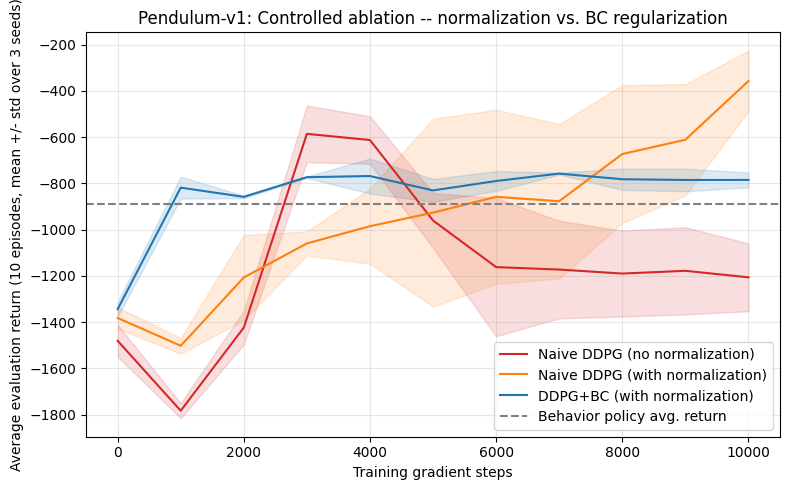

In [19]:
colors = {"naive_no_norm": "tab:red", "naive_norm": "tab:orange", "bc_norm": "tab:blue"}
labels = {
    "naive_no_norm": "Naive DDPG (no normalization)",
    "naive_norm": "Naive DDPG (with normalization)",
    "bc_norm": "DDPG+BC (with normalization)",
}

plt.figure(figsize=(8, 5))
for name, seed_results in all_results.items():
    steps = seed_results[SEED_LIST[0]]["step"]
    returns_by_seed = np.array([seed_results[s]["eval_return"] for s in SEED_LIST])
    mean_ret = returns_by_seed.mean(axis=0)
    std_ret = returns_by_seed.std(axis=0)
    plt.plot(steps, mean_ret, label=labels[name], color=colors[name])
    plt.fill_between(steps, mean_ret - std_ret, mean_ret + std_ret, color=colors[name], alpha=0.15)

plt.axhline(np.mean(behavior_returns), color="gray", linestyle="--", label="Behavior policy avg. return")
plt.xlabel("Training gradient steps")
plt.ylabel("Average evaluation return (10 episodes, mean +/- std over 3 seeds)")
plt.title(f"{ENV_NAME}: Controlled ablation -- normalization vs. BC regularization")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Discussion questions (required).**

1. Compare `naive_no_norm` vs. `naive_norm`. Does normalization alone meaningfully change
   performance or stability here? Give the specific numbers from your table.
2. Compare `naive_norm` vs. `bc_norm`. Does adding the BC term produce a further change beyond
   what normalization alone gave you? Is this consistent with the extrapolation-error story from
   Section 1?
3. Look at the std column in your table. For any one of the three configs, would you have drawn a
   different conclusion if you had only run a single seed (e.g. seed 0 only)? Why might
   single-seed offline RL results be especially likely to mislead, given what causes extrapolation
   error?

**Your answers:**

## 1.

Yes, normalization significantly improves performance.

- `naive_no_norm`: **-1206.1 ± 146.7**
- `naive_norm`: **-357.4 ± 131.0**

The normalized version achieves a much better final return, showing that state normalization improves optimization and helps the actor-critic training become more stable. However, the standard deviation is still relatively large, so normalization alone does not completely remove seed sensitivity.


## 2.

The results are:

- `naive_norm`: **-357.4 ± 131.0**
- `bc_norm`: **-785.0 ± 32.1**

In this experiment, adding BC decreases the average return but reduces variance significantly.

This is partially consistent with the extrapolation-error explanation. The BC term keeps the actor closer to logged actions, which reduces the chance of exploiting incorrect critic estimates and makes training more stable. However, it can also limit the policy improvement by preventing the actor from moving far from the behavior policy.


## 3.

Yes. For example, `naive_norm` has a standard deviation of **131.0**, and `naive_no_norm` has a standard deviation of **146.7**.

A single seed could make one method appear better or worse by chance. Offline RL is especially seed-sensitive because small differences in initialization or sampled batches can change critic errors, and the actor may exploit these errors. Since no new environment data is collected, there is no correction mechanism.


## 7. Required Sweep: Sensitivity to Alpha

This is the one **required** hyperparameter sweep. It is intentionally small: 3 values of
`alpha`, 1 seed, 5,000 steps each (~2-3 minutes total) -- do not scale this up further, it is not
necessary for full credit.


In [20]:
alpha_values = [0.5, 2.5, 10.0]
alpha_results = {}
for a in alpha_values:
    torch.manual_seed(SEED_LIST[0])
    agent = DDPGAgent(state_dim, action_dim, max_action, normalizer=normalizer, use_bc=True, alpha=a)
    sample_rng = make_sample_rng(SEED_LIST[0])
    alpha_results[a] = train_offline(agent, offline_buffer, sample_rng, n_steps=5_000,
                                      batch_size=256, eval_every=1000, eval_episodes=5,
                                      log_prefix=f"[alpha={a}] ")

[alpha=0.5] step      1 | eval return  -1153.3 +- 392.3 | critic_loss 39.678 | actor_loss 3.256
[alpha=0.5] step   1000 | eval return   -781.4 +- 591.6 | critic_loss 0.343 | actor_loss 0.759
[alpha=0.5] step   2000 | eval return   -775.8 +- 587.4 | critic_loss 0.611 | actor_loss 0.692
[alpha=0.5] step   3000 | eval return   -774.1 +- 584.4 | critic_loss 1.386 | actor_loss 0.676
[alpha=0.5] step   4000 | eval return   -774.3 +- 585.4 | critic_loss 2.204 | actor_loss 0.734
[alpha=0.5] step   5000 | eval return   -769.3 +- 579.8 | critic_loss 1.630 | actor_loss 0.638
[alpha=2.5] step      1 | eval return  -1167.8 +- 384.2 | critic_loss 39.678 | actor_loss 5.256
[alpha=2.5] step   1000 | eval return   -713.0 +- 538.4 | critic_loss 0.332 | actor_loss 2.755
[alpha=2.5] step   2000 | eval return   -727.3 +- 547.5 | critic_loss 0.528 | actor_loss 2.689
[alpha=2.5] step   3000 | eval return   -756.3 +- 570.9 | critic_loss 1.173 | actor_loss 2.672
[alpha=2.5] step   4000 | eval return   -744.8 +

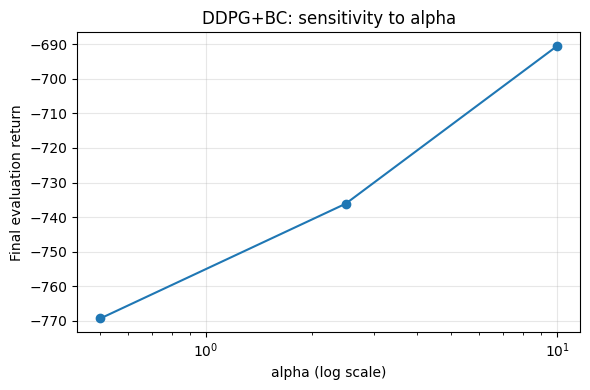

alpha=  0.5: final eval return = -769.3
alpha=  2.5: final eval return = -736.1
alpha= 10.0: final eval return = -690.5


In [21]:
alpha_finals = [alpha_results[a]["eval_return"][-1] for a in alpha_values]

plt.figure(figsize=(6, 4))
plt.plot(alpha_values, alpha_finals, marker="o")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Final evaluation return")
plt.title("DDPG+BC: sensitivity to alpha")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for a, ret in zip(alpha_values, alpha_finals):
    print(f"alpha={a:>5}: final eval return = {ret:.1f}")

**Discussion question (required).** As $\alpha \to 0$, the Q-maximization term vanishes and the actor approaches pure behavior cloning; as $\alpha \to \infty$, the critic-maximization term dominates under the stated loss convention. Does your sweep show the expected trade-off? What does the $\alpha$ that performs best in your sweep suggest about the relative trust you should place in this dataset's actions vs. the critic's value estimates?

**Your answer:**

*(write your response here after running the sweep)*


## 8. Optional / Extra Credit

None of the items below are required -- the project is complete without them. Each has a
bounded extra cost if you choose to attempt it.

1. **Dataset-size / behavior-noise sweep** (~3 min compute, ~15 min write-up). Vary `n_episodes`
   and `noise_std` in `collect_offline_dataset` and re-run the 3-way comparison at reduced scale.
   How does the gap between `naive_norm` and `bc_norm` change with dataset size/quality?
2. **Tiny 2-critic ensemble** (~10-15 min implementation, ~3 min compute). A minimal,
   uncertainty-based alternative to BC regularization (conceptually related to An et al., 2021,
   but with only 2 critics instead of a large ensemble). A scaffold is provided below.


In [22]:
# OPTIONAL / EXTRA CREDIT: dataset-size and behavior-noise sensitivity sweep.
# Uncomment and adapt as needed -- budget roughly 3 extra minutes of compute
# per value tried (see the time budget table at the top of the notebook).

# dataset_size_values = [20, 50, 200]
# for n_ep in dataset_size_values:
#     small_buffer, _ = collect_offline_dataset(env, n_episodes=n_ep, noise_std=0.6)
#     small_normalizer = RunningNormalizer(small_buffer.states[: len(small_buffer)])
#     torch.manual_seed(SEED_LIST[0])
#     agent = DDPGAgent(state_dim, action_dim, max_action, normalizer=small_normalizer,
#                        use_bc=True, alpha=2.5)
#     sample_rng = make_sample_rng(SEED_LIST[0])
#     hist = train_offline(agent, small_buffer, sample_rng, n_steps=5_000, eval_episodes=5,
#                           log_prefix=f"[n_episodes={n_ep}] ")

# noise_values = [0.1, 0.6, 1.5]
# for noise in noise_values:
#     noisy_buffer, _ = collect_offline_dataset(env, n_episodes=200, noise_std=noise)
#     # ... same pattern as above, comparing across noise levels instead of dataset size

In [23]:
# OPTIONAL / EXTRA CREDIT: a minimal 2-critic ensemble for an uncertainty-based
# penalty, as an alternative (not required) way to mitigate extrapolation error.

class TinyEnsembleCritic(nn.Module):
    """Two independent critics Q1, Q2.

    This is only the small ensemble building block. A full extra-credit agent
    would train both critics and use ``clipped_min`` in its TD target and actor
    objective.
    """

    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()
        self.q1 = Critic(state_dim, action_dim, hidden_dim)
        self.q2 = Critic(state_dim, action_dim, hidden_dim)

    def forward(self, state, action):
        return self.q1(state, action), self.q2(state, action)

    def clipped_min(self, state, action):
        """Elementwise minimum of the two critics' Q estimates."""
        q1, q2 = self(state, action)
        return torch.minimum(q1, q2)


## 9. Connecting to the Literature

- **TD3+BC (Fujimoto & Gu, 2021).** Our DDPG+BC agent is a direct simplification of TD3+BC down
  to a single critic and single actor (i.e. DDPG instead of TD3's twin critics, delayed policy
  updates, and target policy smoothing). The core idea we borrowed is exactly TD3+BC's
  "minimalist" recipe: add a plain BC term to the actor loss, scale it adaptively against the
  $Q$-term, and normalize states. Notably, the original paper's own ablations *also* separate the
  BC term from normalization -- the pattern you should expect from Section 6 mirrors theirs:
  normalization alone tends to be a minor, mostly-stability effect, while the BC term is what
  principally addresses extrapolation error.

- **BRAC (Wu et al., 2019).** BRAC frames a *general family* of behavior-regularized
  actor-critic objectives, where the regularizer can be a KL divergence, MMD, or other divergence
  between $\pi_\theta$ and an estimated $\pi_\beta$, with a learned or fixed regularization
  coefficient. Our BC term is a special case of this general framework. Our fixed,
  dataset-adaptive $\lambda$ plays the same conceptual role as BRAC's regularization coefficient,
  computed with a simpler, non-learned heuristic.

- **Diversified Q-Ensembles (An et al., 2021).** This line of work does not regularize the policy
  at all. Instead it trains many critics and penalizes actions where they *disagree*, directly
  targeting epistemic uncertainty about OOD actions. It typically needs more critics and compute
  (10+ networks in the original paper) than fits this notebook's required budget -- see the
  optional 2-critic scaffold in Section 8.

- **Takeaway.** Despite its simplicity, the BC-regularized actor loss implemented in this
  notebook is a genuinely strong, widely-used offline RL baseline -- frequently competitive with
  much more complex methods on standard offline RL benchmarks (e.g. D4RL).


## 10. Final Output

**Submission checklist:**
- [ ] Notebook runs top-to-bottom with no `NotImplementedError` remaining.
- [ ] All "Your answer" cells are filled in.
- [ ] All required plots (Sections 6 and 7) are present with output visible.


# project Question 1: Extrapolation Error and Behavior Regularization

## 1. Why are the same actor-critic updates less dangerous in online RL?

In online RL, the agent continuously collects new data from its current policy. If the actor selects bad actions, these actions are observed in the environment and the critic can correct its estimates.

In offline RL, the dataset is fixed, so critic errors for unsupported actions cannot be corrected.


## 2. How does the BC term help? Why does it not guarantee support? What performance ceiling can it impose?

The BC term penalizes the distance between the learned action and the logged action:

$
\|\pi_\theta(s)-a\|^2
$

This encourages the actor to stay close to actions in the dataset, reducing the probability of selecting out-of-distribution actions where the critic may be inaccurate.

However, it does not guarantee support for a multimodal behavior policy because a deterministic policy may learn an average action between multiple valid modes, even if that action was never present in the dataset.

Strong behavior regularization can impose a performance ceiling because the learned policy may remain close to the behavior policy instead of discovering better actions.


## 3. Why must the TD target use slowly moving target networks and be detached from autograd?

Target networks provide a slowly changing target, which makes critic learning more stable.

The TD target must be detached because it should be treated as a fixed regression target. If gradients flow through the target network, the critic update becomes unstable because both the prediction and target change together.


## 4. Why should time-limit truncations retain the bootstrap term whereas true terminations should not?

For true termination, the episode has ended and there is no future reward, so the bootstrap term should be removed.

For time-limit truncation, the episode only stopped because of the environment step limit. The underlying MDP continues, so the future value should still be included.


# project Question 2: Ablations, Multi-Seed Evidence, and Alpha Sensitivity

## 1. Compare naive DDPG with and without state normalization.

Normalization has a large positive effect.

- Without normalization:
  $
  -1206.1 \pm 146.7
  $

- With normalization:
  $
  -357.4 \pm 131.0
  $

The normalized agent achieves much better performance, showing that normalization improves learning stability and optimization.


## 2. Compare normalized naive DDPG with normalized DDPG+BC.

Adding BC changes:

- `naive_norm`:
  $
  -357.4 \pm 131.0
  $

- `bc_norm`:
  $
  -785.0 \pm 32.1
  $

The BC version performs worse in mean return but has much lower variance.

This suggests that BC successfully reduces instability caused by extrapolation error, but in this dataset it also restricts improvement because the actor is forced to stay closer to behavior actions.


## 3. Could a single seed lead to a different conclusion?

Yes.

Offline actor-critic methods can be highly sensitive to random initialization and sampling because the critic may develop different value estimation errors. The actor then optimizes these errors differently.

Therefore, a single seed could incorrectly suggest that one method is better. Multi-seed evaluation gives a more reliable comparison.


## 4. Interpret the alpha sweep.

The sweep results are:

| α | Final return |
|---|---:|
| 0.5 | -769.3 |
| 2.5 | -736.1 |
| 10.0 | -690.5 |

Under this loss convention:

$
\alpha \rightarrow 0
$

makes the BC term dominate, approaching behavior cloning.

$
\alpha \rightarrow \infty
$

makes the critic maximization term dominate, approaching standard DDPG.

The best value in the sweep is **α = 10**, suggesting that the learned critic provides useful information beyond simply copying the dataset actions. However, some behavior regularization is still valuable to reduce the risk of exploiting critic errors.
